In [45]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/organizations/uciml/adult-census-income/adult.csv


In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [47]:
sns.set_theme(style='whitegrid')

# Dataset loading

In [48]:
df=pd.read_csv("/kaggle/input/datasets/organizations/uciml/adult-census-income/adult.csv")

In [49]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


Target: Is the person earnning more than 50k

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


No null good

In [51]:
df.duplicated().sum()

np.int64(24)

In [52]:
df.drop_duplicates(inplace=True)

In [53]:
for col in df.columns:
    print(f"{col}:{df[col].nunique()}")

age:73
workclass:9
fnlwgt:21648
education:16
education.num:16
marital.status:7
occupation:15
relationship:6
race:5
sex:2
capital.gain:119
capital.loss:92
hours.per.week:94
native.country:42
income:2


In [54]:
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32537.000000,3.253700e+04,32537.000000,32537.000000,32537.000000,32537.000000
mean,38.585549,1.897808e+05,10.081815,1078.443741,87.368227,40.440329
std,13.637984,1.055565e+05,2.571633,7387.957424,403.101833,12.346889
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.369930e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


# EDA-Preprocessing

<Axes: xlabel='age', ylabel='Count'>

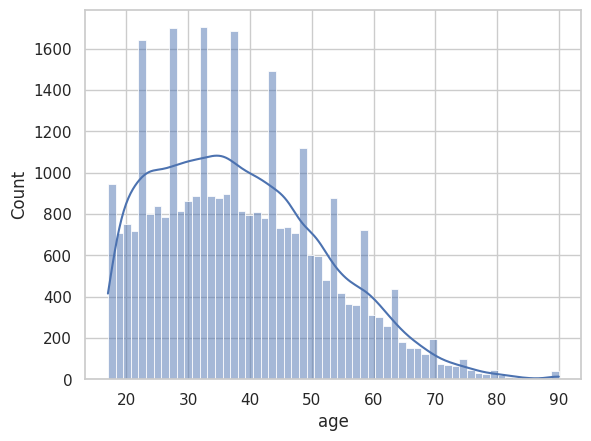

In [55]:
sns.histplot(x=df['age'],kde=True)

Age is very much right skewed

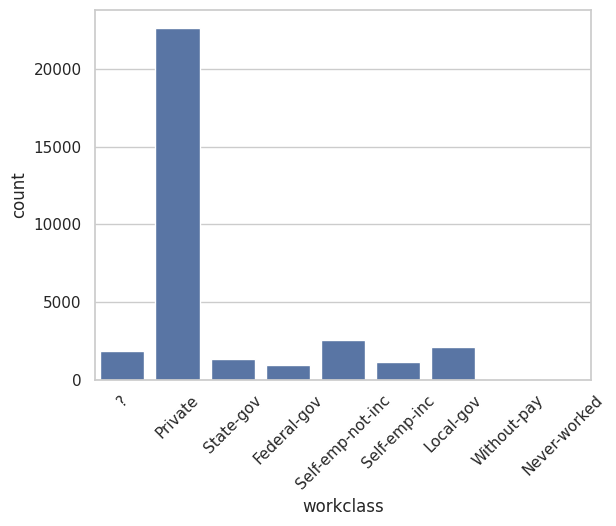

workclass
Private             22673
Self-emp-not-inc     2540
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

In [56]:
df['workclass'].unique()
sns.countplot(x=df['workclass'])
plt.xticks(rotation=45)
plt.show()
df['workclass'].value_counts()

Most of the people are working in private sector,
? is not defined and few in number so droping it.

In [57]:
df.replace("?", pd.NA, inplace=True)
df.dropna(inplace=True)

In [58]:
df.shape

(30139, 15)

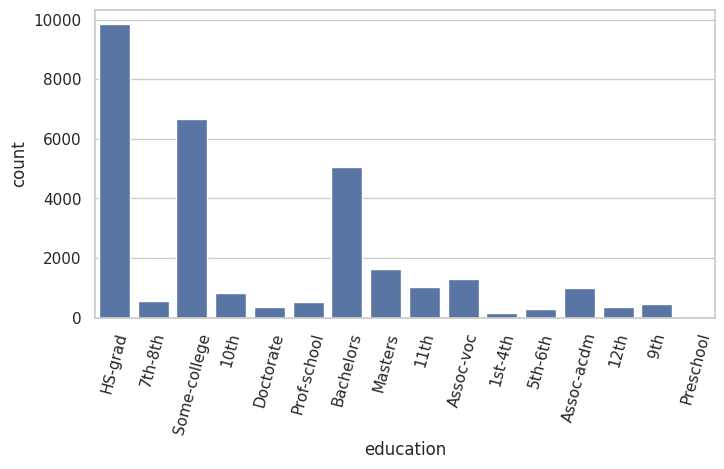

education
HS-grad         9834
Some-college    6669
Bachelors       5042
Masters         1626
Assoc-voc       1307
11th            1048
Assoc-acdm      1008
10th             820
7th-8th          556
Prof-school      542
9th              455
12th             377
Doctorate        375
5th-6th          287
1st-4th          149
Preschool         44
Name: count, dtype: int64

In [59]:
plt.figure(figsize=(8,4))
sns.countplot(x=df['education'])
plt.xticks(rotation=75)
plt.show()
df['education'].value_counts()

In [60]:
df.drop(columns='education.num',inplace=True,axis=1)

* Both columns education and education.num are same difference is one is divided in categories other is based on level.
* Keeping eduction columns for betterment of project


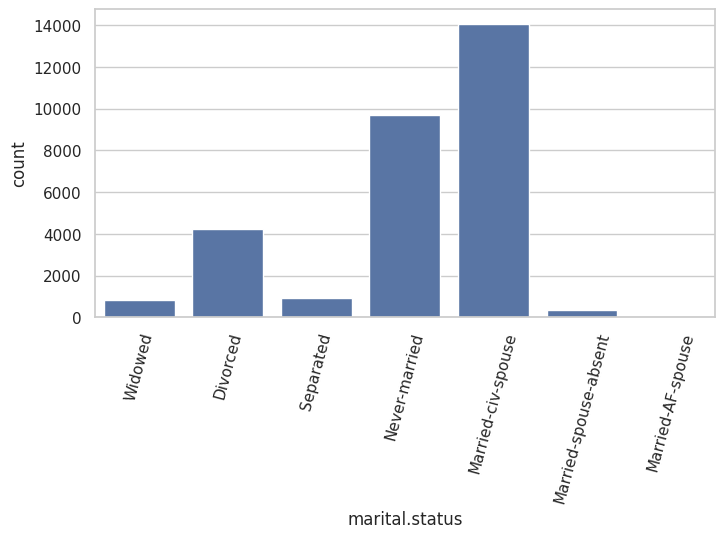

marital.status
Married-civ-spouse       14059
Never-married             9711
Divorced                  4212
Separated                  939
Widowed                    827
Married-spouse-absent      370
Married-AF-spouse           21
Name: count, dtype: int64

In [61]:
plt.figure(figsize=(8,4))
sns.countplot(x=df['marital.status'])
plt.xticks(rotation=75)
plt.show()
df['marital.status'].value_counts()

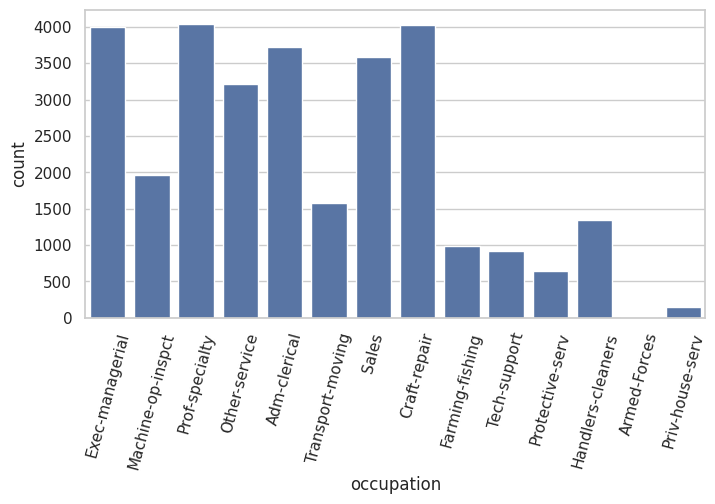

occupation
Prof-specialty       4034
Craft-repair         4025
Exec-managerial      3991
Adm-clerical         3719
Sales                3584
Other-service        3209
Machine-op-inspct    1964
Transport-moving     1572
Handlers-cleaners    1349
Farming-fishing       987
Tech-support          911
Protective-serv       644
Priv-house-serv       141
Armed-Forces            9
Name: count, dtype: int64

In [62]:
plt.figure(figsize=(8,4))
sns.countplot(x=df['occupation'])
plt.xticks(rotation=75)
plt.show()
df['occupation'].value_counts()

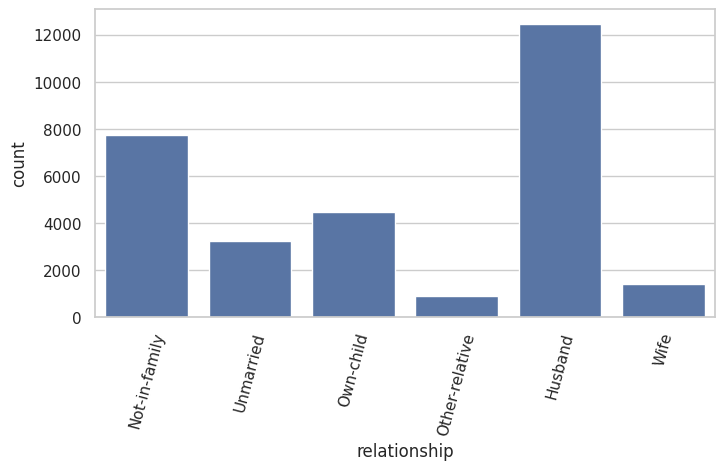

relationship
Husband           12457
Not-in-family      7714
Own-child          4462
Unmarried          3211
Wife               1406
Other-relative      889
Name: count, dtype: int64

In [63]:
plt.figure(figsize=(8,4))
sns.countplot(x=df['relationship'])
plt.xticks(rotation=75)
plt.show()
df['relationship'].value_counts()

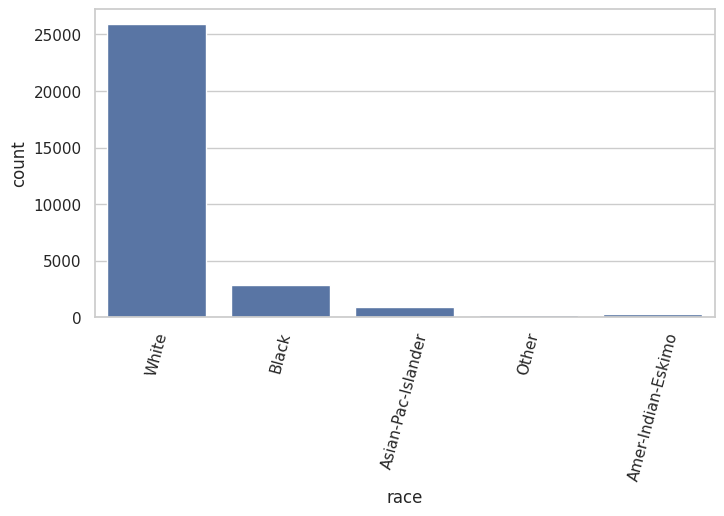

race
White                 25912
Black                  2816
Asian-Pac-Islander      894
Amer-Indian-Eskimo      286
Other                   231
Name: count, dtype: int64

In [64]:
plt.figure(figsize=(8,4))
sns.countplot(x=df['race'])
plt.xticks(rotation=75)
plt.show()
df['race'].value_counts()

very few race after white anbd black , so will club them in one as others

In [65]:
df["race"] = df["race"].replace({
    "Asian-Pac-Islander": "Other",
    "Amer-Indian-Eskimo": "Other"
})

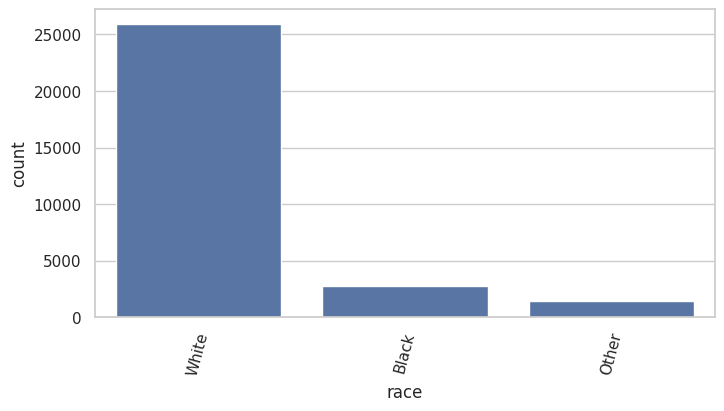

race
White    25912
Black     2816
Other     1411
Name: count, dtype: int64

In [66]:
plt.figure(figsize=(8,4))
sns.countplot(x=df['race'])
plt.xticks(rotation=75)
plt.show()
df['race'].value_counts()

In [67]:
df['sex']=df['sex'].map({
    'Male':1,
    'Female':0
})

mapped male as 1 and female as 0

In [68]:
df['income']=df['income'].map({
    "<=50K":1,
    ">50K":0
})

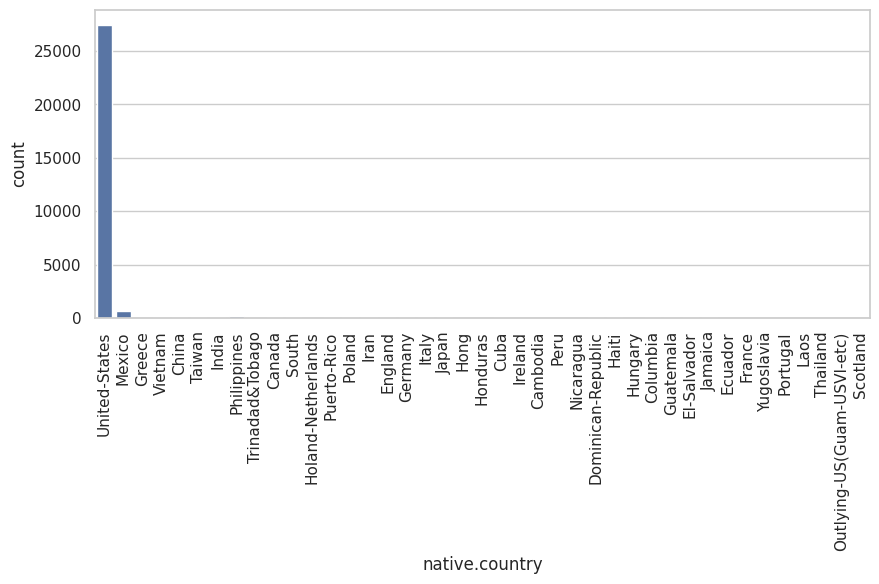

native.country
United-States                 27487
Mexico                          606
Philippines                     188
Germany                         128
Puerto-Rico                     109
Canada                          107
El-Salvador                     100
India                           100
Cuba                             92
England                          86
Jamaica                          80
South                            71
Italy                            68
China                            68
Dominican-Republic               67
Vietnam                          64
Guatemala                        61
Japan                            59
Poland                           56
Columbia                         56
Taiwan                           42
Haiti                            42
Iran                             42
Portugal                         34
Nicaragua                        33
Peru                             30
Greece                           29
Ecuador      

In [69]:
plt.figure(figsize=(10,4))
sns.countplot(x=df['native.country'])
plt.xticks(rotation=90)
plt.show()
df['native.country'].value_counts()

There are so many contries but most of data is of usa therefore making a new column on the basis of region like North America and other

In [70]:
region_map = {
    "United-States": "North America",
    "Canada": "North America",
    "Mexico": "North America",

    "India": "Asia",
    "China": "Asia",
    "Japan": "Asia",
    "Philippines": "Asia",
    "Taiwan": "Asia",
    "Iran": "Asia",
    "Vietnam": "Asia",
    "Thailand": "Asia",
    "Cambodia": "Asia",
    "Laos": "Asia",
    "Hong": "Asia",

    "England": "Europe",
    "Germany": "Europe",
    "France": "Europe",
    "Italy": "Europe",
    "Ireland": "Europe",
    "Portugal": "Europe",
    "Greece": "Europe",
    "Poland": "Europe",
    "Hungary": "Europe",
    "Scotland": "Europe",
    "Yugoslavia": "Europe",
    "Holand-Netherlands": "Europe",

    "Cuba": "Central America & Caribbean",
    "Puerto-Rico": "Central America & Caribbean",
    "Jamaica": "Central America & Caribbean",
    "Dominican-Republic": "Central America & Caribbean",
    "Haiti": "Central America & Caribbean",
    "Guatemala": "Central America & Caribbean",
    "Honduras": "Central America & Caribbean",
    "Nicaragua": "Central America & Caribbean",
    "El-Salvador": "Central America & Caribbean",
    "Trinadad&Tobago": "Central America & Caribbean",

    "Columbia": "South America",
    "Peru": "South America",
    "Ecuador": "South America",

    "South": "Africa",
    "Outlying-US(Guam-USVI-etc)": "Oceania"
}

df["region"] = df["native.country"].map(region_map)

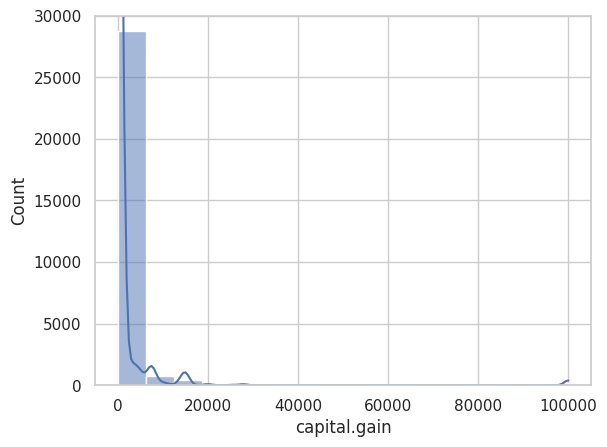

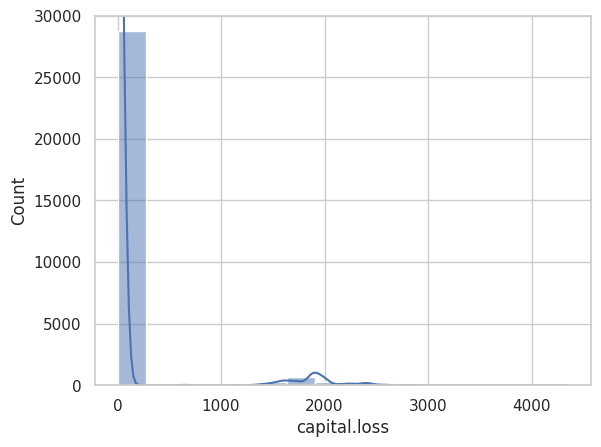

In [71]:
sns.histplot(x=df['capital.gain'],kde=True)
plt.ylim(0,30000)
plt.show()
sns.histplot(x=df['capital.loss'],kde=True)
plt.ylim(0,30000)
plt.show()

<Axes: >

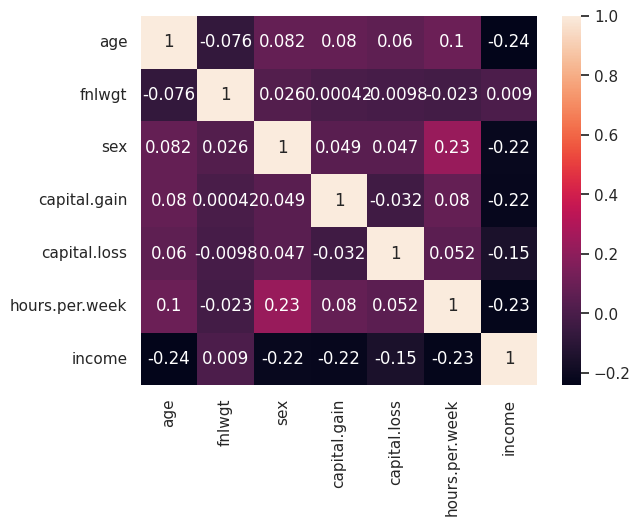

In [72]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

* Age and income have negative correlation suggest older you are more likely to earn less than 50k.
* Same goes with sex,capital_gain,capital_loss,working hours.

In [73]:
cat_columns=['workclass','education', 'marital.status',
       'occupation', 'relationship', 'race', 'sex','region']

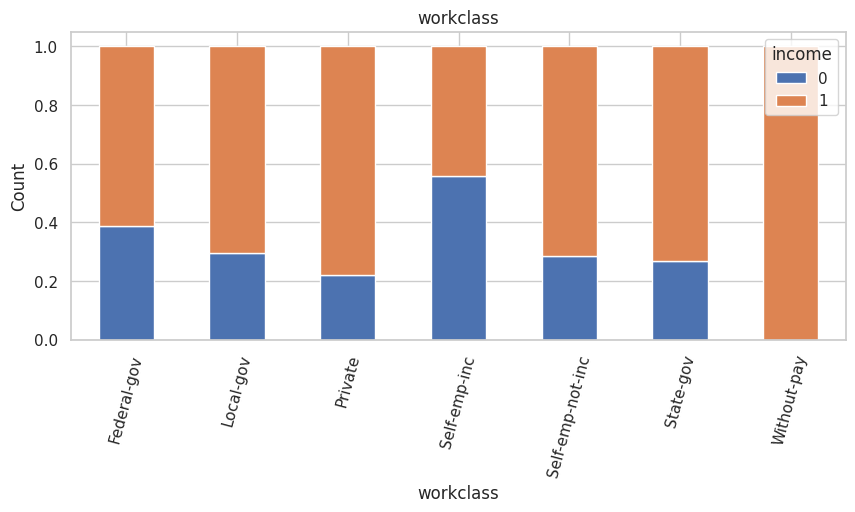

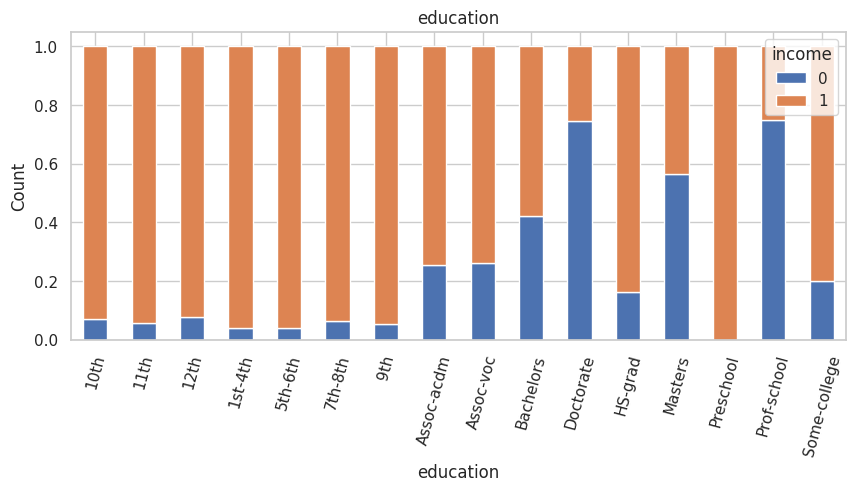

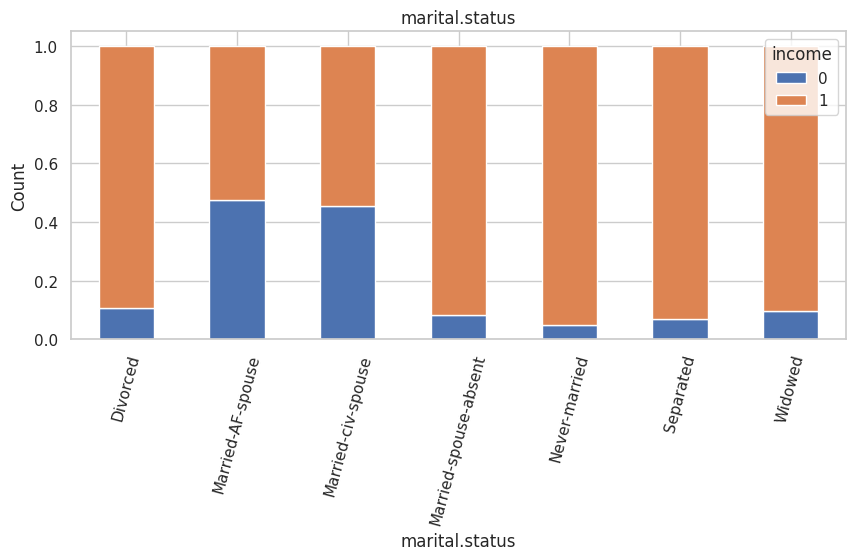

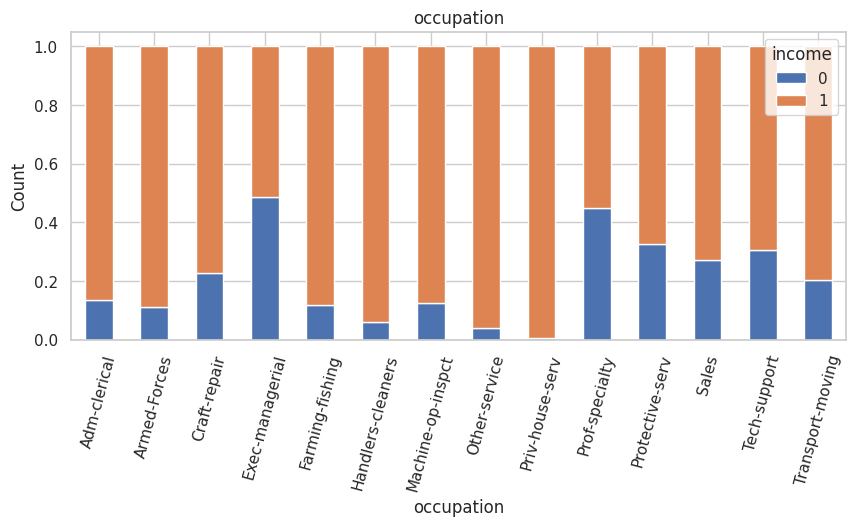

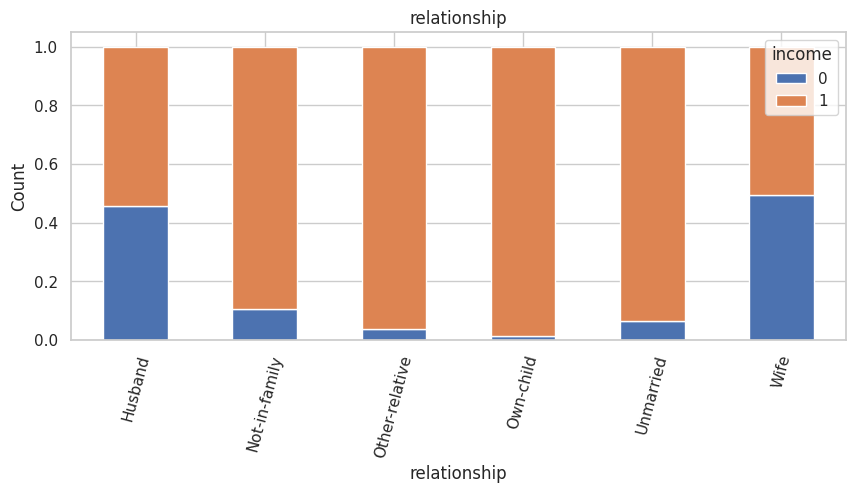

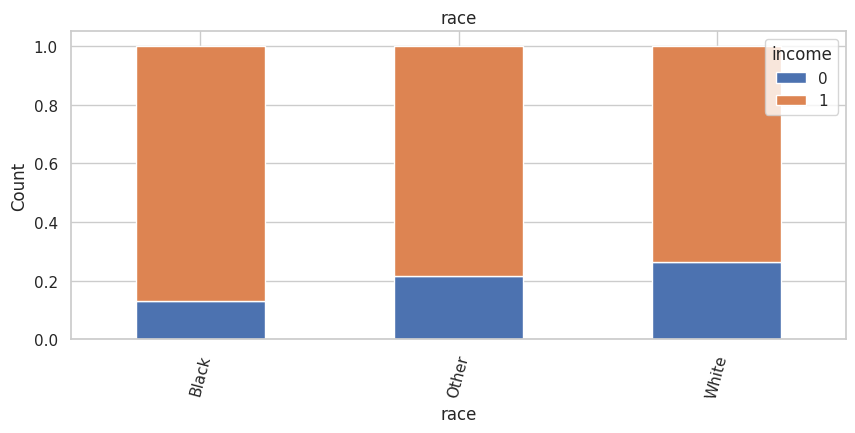

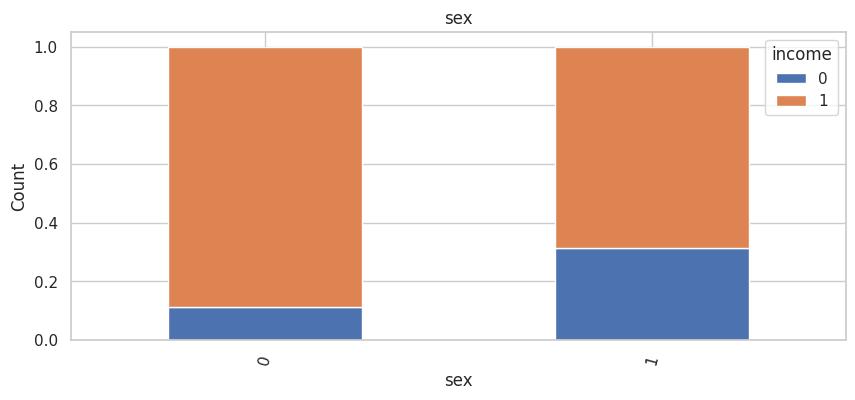

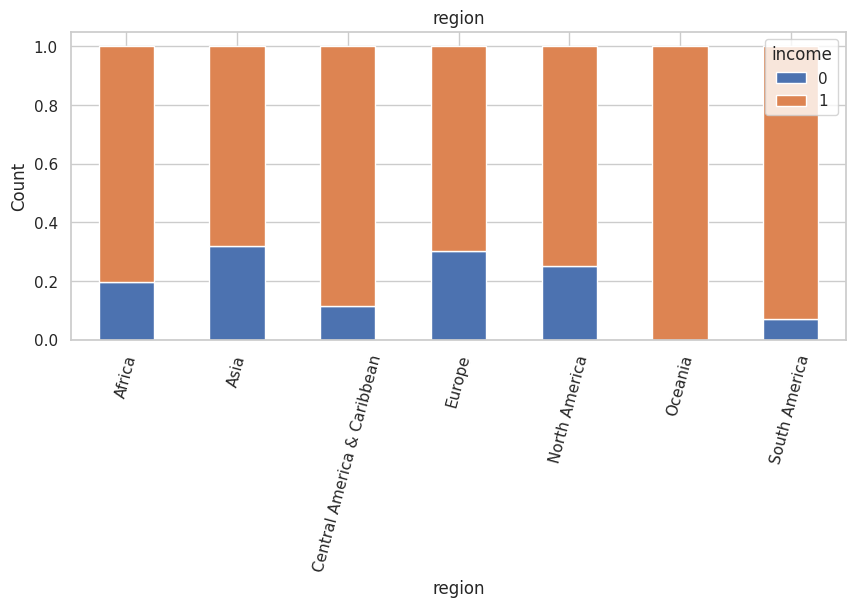

In [74]:
for col in cat_columns:
    pd.crosstab(df[col], df["income"],normalize="index").plot(
        kind="bar",
        stacked=True,
        figsize=(10, 4)
    )

    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=75)
    plt.show()

# Model_Selection

In [75]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (accuracy_score,
                                f1_score,
                                recall_score,
                                precision_score
                                ,confusion_matrix,
                                roc_auc_score,
                                classification_report)
from sklearn.model_selection import RandomizedSearchCV

In [76]:
df.drop(columns='native.country',inplace=True)

In [77]:
df_copy=pd.get_dummies(df,drop_first=True)

In [78]:
df_copy=df_copy.astype(int)

In [79]:
df_copy.head()

,age,fnlwgt,sex,capital.gain,capital.loss,hours.per.week,income,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,...,relationship_Unmarried,relationship_Wife,race_Other,race_White,region_Asia,region_Central America & Caribbean,region_Europe,region_North America,region_Oceania,region_South America
1,82,132870,0,0,4356,18,1,0,1,0,...,0,0,0,1,0,0,0,1,0,0
3,54,140359,0,0,3900,40,1,0,1,0,...,1,0,0,1,0,0,0,1,0,0
4,41,264663,0,0,3900,40,1,0,1,0,...,0,0,0,1,0,0,0,1,0,0
5,34,216864,0,0,3770,45,1,0,1,0,...,1,0,0,1,0,0,0,1,0,0
6,38,150601,1,0,3770,40,1,0,1,0,...,1,0,0,1,0,0,0,1,0,0


In [80]:
x=df_copy.drop(columns=['income','fnlwgt'],axis=1)
y=df_copy['income']

In [81]:
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.33,random_state=42)

In [82]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [83]:
model1={
    "logistic regression":LogisticRegression(),
    "KNN":KNeighborsClassifier(n_neighbors=5)
    # "SVM":SVC(kernel='linear',probability=True,random_state=42)
}
model2={
    "Decision Tree":DecisionTreeClassifier(random_state=42),
    "Random Forest":RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1),
    "GradientBoostingClassifier":GradientBoostingClassifier(random_state=42),
    "GaussianNB":GaussianNB()
}

In [84]:
results1= []
for name,model in model1.items():
    model.fit(X_train_scaled,y_train)
    y_pred=model.predict(X_test_scaled)

    accuracy=accuracy_score(y_test,y_pred)
    precision=precision_score(y_test,y_pred)
    recall=recall_score(y_test,y_pred)
    f1=f1_score(y_test,y_pred)
    results1.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
    })
    
    results_df = pd.DataFrame(results1).sort_values("F1", ascending=False)

In [85]:
results_df

,Model,Accuracy,Precision,Recall,F1
0,logistic regression,0.848482,0.879944,0.925343,0.902073
1,KNN,0.816911,0.867115,0.894281,0.880488


In [86]:
results2= []
for name,model in model2.items():
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)

    accuracy=accuracy_score(y_test,y_pred)
    precision=precision_score(y_test,y_pred)
    recall=recall_score(y_test,y_pred)
    f1=f1_score(y_test,y_pred)
    results2.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
    })
    
    results_df2= pd.DataFrame(results2).sort_values("F1", ascending=False)

In [87]:
results_df2

,Model,Accuracy,Precision,Recall,F1
2,GradientBoostingClassifier,0.864368,0.881165,0.948007,0.913365
1,Random Forest,0.843857,0.884337,0.912278,0.898090
3,GaussianNB,0.821536,0.904722,0.853220,0.878216
0,Decision Tree,0.811482,0.883765,0.863618,0.873576


# Tunning of best model

In [89]:
model_gbc=GradientBoostingClassifier()
param_grid = {
    "n_estimators": [50,100,150,200],
    "learning_rate": [0.01, 0.05, 0.1,1],
    "max_depth": [3, 5, 7],
    "subsample": [0.8, 1.0],
    "min_samples_split": [2, 5, 10]
}
cv=RandomizedSearchCV(estimator=model_gbc,
    param_distributions=param_grid,n_iter=10,cv=2,random_state=42,return_train_score=False,n_jobs=-1)
cv.fit(X_train,y_train)
y_pred=cv.predict(X_test)

print("Best Parameters:", cv.best_params_)
print("Best CV Score:", cv.best_score_)

best_model = cv.best_estimator_

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_prob):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Best Parameters: {'subsample': 0.8, 'n_estimators': 150, 'min_samples_split': 2, 'max_depth': 5, 'learning_rate': 0.1}
Best CV Score: 0.8620809065299557
Accuracy : 0.8706
Precision: 0.8949
Recall   : 0.9387
F1 Score : 0.9163
ROC AUC  : 0.9207

Confusion Matrix:
[[1618  827]
 [ 460 7041]]

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.66      0.72      2445
           1       0.89      0.94      0.92      7501

    accuracy                           0.87      9946
   macro avg       0.84      0.80      0.82      9946
weighted avg       0.87      0.87      0.87      9946



In [90]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_model.feature_importances_
}).sort_values("Importance", ascending=False)

print(importance.head(15))

                              Feature  Importance
27  marital.status_Married-civ-spouse    0.345264
2                        capital.gain    0.197303
0                                 age    0.076995
3                        capital.loss    0.074119
4                      hours.per.week    0.053406
40          occupation_Prof-specialty    0.031665
19                education_Bachelors    0.029959
34         occupation_Exec-managerial    0.027431
22                  education_Masters    0.020022
24              education_Prof-school    0.011791
20                education_Doctorate    0.010884
21                  education_HS-grad    0.009849
8          workclass_Self-emp-not-inc    0.009206
38           occupation_Other-service    0.008792
49                  relationship_Wife    0.007795


# Model Exporting

In [91]:
import joblib

joblib.dump(best_model, "income_predictor_model.pkl")

['income_predictor_model.pkl']

In [99]:
x.columns.tolist()

['age',
 'sex',
 'capital.gain',
 'capital.loss',
 'hours.per.week',
 'workclass_Local-gov',
 'workclass_Private',
 'workclass_Self-emp-inc',
 'workclass_Self-emp-not-inc',
 'workclass_State-gov',
 'workclass_Without-pay',
 'education_11th',
 'education_12th',
 'education_1st-4th',
 'education_5th-6th',
 'education_7th-8th',
 'education_9th',
 'education_Assoc-acdm',
 'education_Assoc-voc',
 'education_Bachelors',
 'education_Doctorate',
 'education_HS-grad',
 'education_Masters',
 'education_Preschool',
 'education_Prof-school',
 'education_Some-college',
 'marital.status_Married-AF-spouse',
 'marital.status_Married-civ-spouse',
 'marital.status_Married-spouse-absent',
 'marital.status_Never-married',
 'marital.status_Separated',
 'marital.status_Widowed',
 'occupation_Armed-Forces',
 'occupation_Craft-repair',
 'occupation_Exec-managerial',
 'occupation_Farming-fishing',
 'occupation_Handlers-cleaners',
 'occupation_Machine-op-inspct',
 'occupation_Other-service',
 'occupation_Priv-h